In [42]:
import sys
import os
nb_dir = os.path.split(os.getcwd())[0]
if nb_dir not in sys.path:
    sys.path.append(nb_dir)

import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
from scipy import stats as scipy_stats
from statsmodels.stats.multitest import multipletests
from analysis import get_connection, compute_frequencies, compare_responders
from analysis.db import CELL_TYPES

In [43]:
conn = get_connection()
# freq = compute_frequencies(conn)
freq, stats_df = compare_responders(conn)
conn.close()

print(f"Rows: {len(freq)}")
print(freq.head(10).to_string(index=False))

Rows: 9840
     sample subject_id response sex  age project_id  time population  percentage
sample00000     sbj000       no   M   57       prj1     0     b_cell   11.702105
sample00006     sbj002       no   M   50       prj1     0     b_cell    5.910357
sample00009     sbj003       no   M   52       prj1     0     b_cell    7.983636
sample00024     sbj008      yes   F   53       prj1     0     b_cell    7.554342
sample00060     sbj020      yes   F   62       prj1     0     b_cell   10.658334
sample00066     sbj022      yes   M   79       prj1     0     b_cell    7.505313
sample00072     sbj024       no   M   55       prj1     0     b_cell    9.325628
sample00075     sbj025      yes   F   61       prj1     0     b_cell   13.828538
sample00081     sbj027       no   F   59       prj1     0     b_cell   10.285573
sample00123     sbj041       no   F   62       prj1     0     b_cell    8.469094


In [44]:
freq

,sample,subject_id,response,sex,age,project_id,time,population,percentage
0,sample00000,sbj000,no,M,57,prj1,0,b_cell,11.702105
1,sample00006,sbj002,no,M,50,prj1,0,b_cell,5.910357
2,sample00009,sbj003,no,M,52,prj1,0,b_cell,7.983636
3,sample00024,sbj008,yes,F,53,prj1,0,b_cell,7.554342
4,sample00060,sbj020,yes,F,62,prj1,0,b_cell,10.658334
...,...,...,...,...,...,...,...,...,...
9835,sample10445,sbj3481,yes,M,54,prj3,14,monocyte,20.335831
9836,sample10457,sbj3485,no,F,61,prj3,14,monocyte,15.950433
9837,sample10472,sbj3490,no,M,67,prj3,14,monocyte,12.823078
9838,sample10475,sbj3491,no,F,55,prj3,14,monocyte,14.332828


In [45]:
print(freq.tail(10).to_string(index=False))

     sample subject_id response sex  age project_id  time population  percentage
sample10388    sbj3462      yes   M   70       prj3    14   monocyte   15.122653
sample10394    sbj3464      yes   M   59       prj3    14   monocyte   24.315096
sample10397    sbj3465       no   M   60       prj3    14   monocyte   22.244241
sample10412    sbj3470      yes   F   50       prj3    14   monocyte   15.858676
sample10418    sbj3472       no   F   70       prj3    14   monocyte   24.772825
sample10445    sbj3481      yes   M   54       prj3    14   monocyte   20.335831
sample10457    sbj3485       no   F   61       prj3    14   monocyte   15.950433
sample10472    sbj3490       no   M   67       prj3    14   monocyte   12.823078
sample10475    sbj3491       no   F   55       prj3    14   monocyte   14.332828
sample10493    sbj3497      yes   M   71       prj3    14   monocyte   18.673035


In [46]:
freq.shape

(9840, 9)

In [47]:
# Compare the differences in cell population relative frequencies of 
# melanoma patients receiving miraclib who respond (responders) versus those 
# who do not (non-responders), with the overarching aim of predicting response 
# to the treatment miraclib. Response information can be found in column "response", 
# with value "yes" for responding and value "no" for non-responding. Please only include PBMC samples.



# Part 3: Generalized Estimating Equations (GEE)

Each subject has 3 repeated PBMC samples (day 0, 7, 14). Observations are **clustered within subjects** ; non-parametric tests and parametric t-tests assume independence, which is violated here.

**GEE over LME**
GEE gives population-averaged estimates (the effect of response across the whole cohort), which is what we want for a clinical trial. LME gives subject-specific estimates. GEE is also more robust as it uses sandwich (robust) standard errors that remain valid even if the correlation structure is slightly wrong.

**Model:** `percentage ~ response * time + sex + age + C(project_id)`  
**Cluster:** `subject_id` (each patient = 1 cluster, 3 observations inside)  
**Family:** Gaussian with identity link (percentage is continuous, no boundary effects)  
**Correlation structure:** Exchangeable (constant within-subject correlation across time points)

| Term | Rationale |
|------|-----------|
| `response` | Baseline difference between responders and non-responders |
| `time` | How cell frequencies change over the course of treatment |
| `response:time` | **Key question:** do responders show a different trajectory over time? |
| `sex` | Immune composition may differs by sex |
| `age` | older patients may have different baseline profiles |
| `C(project_id)` | Controls for cohort/batch effects across projects |

`response:sex` was **excluded** as no strong prior hypothesis for a sex-specific treatment effect, and including speculative interactions inflates standard errors and risks false positives (parsimony principle).

In [48]:
conn = get_connection()

total_subjects = pd.read_sql_query("SELECT COUNT(DISTINCT subject_id) as n FROM subjects", conn).iloc[0,0]
total_samples  = pd.read_sql_query("SELECT COUNT(*) as n FROM samples", conn).iloc[0,0]

cohort = pd.read_sql_query("""
    SELECT sub.subject_id, sub.response, s.sample_id, s.time_from_treatment_start
    FROM samples s
    JOIN subjects    sub ON s.subject_id    = sub.subject_id
    JOIN conditions  c   ON sub.condition_id = c.condition_id
    JOIN treatments  t   ON sub.treatment_id = t.treatment_id
    WHERE c.condition_name = 'melanoma'
      AND t.treatment_name = 'miraclib'
      AND s.sample_type    = 'PBMC'
      AND sub.response IN ('yes', 'no')
""", conn)

conn.close()

subjects = cohort.drop_duplicates("subject_id")

print(f"Total dataset:          {total_subjects} subjects, {total_samples} samples")
print(f"After filter:           {cohort['subject_id'].nunique()} subjects (cluster by time points), {len(cohort)} samples")
print(f"Time points:            {sorted(cohort['time_from_treatment_start'].unique())}")
print(f"Obs per cluster:        {cohort.groupby('subject_id')['time_from_treatment_start'].nunique().value_counts().to_dict()}")
print(f"Responders (yes):       {(subjects.response == 'yes').sum()}")
print(f"Non-responders (no):    {(subjects.response == 'no').sum()}")
print(f"\n{cohort['subject_id'].nunique()} clusters >> 40 minimum threshold for reliable robust SEs in GEE")

Total dataset:          3500 subjects, 10500 samples
After filter:           656 subjects (cluster by time points), 1968 samples
Time points:            [np.int64(0), np.int64(7), np.int64(14)]
Obs per cluster:        {3: 656}
Responders (yes):       331
Non-responders (no):    325

656 clusters >> 40 minimum threshold for reliable robust SEs in GEE


In [78]:
from statsmodels.genmod.generalized_estimating_equations import GEE
from statsmodels.genmod.families import Gaussian
from statsmodels.genmod.cov_struct import Independence, Exchangeable, Autoregressive

# Start with b_cell to understand the model output
pop_df = freq[freq.population == "b_cell"].copy()

# Fit with exchangeable correlation first
model  = GEE.from_formula(
    "percentage ~ response * time + sex + age + C(project_id)",
    groups="subject_id",
    data=pop_df,
    family=Gaussian(),
    cov_struct=Exchangeable(),
)
result = model.fit()
print(result.summary())

                               GEE Regression Results                              
Dep. Variable:                  percentage   No. Observations:                 1968
Model:                                 GEE   No. clusters:                      656
Method:                        Generalized   Min. cluster size:                   3
                      Estimating Equations   Max. cluster size:                   3
Family:                           Gaussian   Mean cluster size:                 3.0
Dependence structure:         Exchangeable   Num. iterations:                     2
Date:                     Sat, 21 Feb 2026   Scale:                          10.332
Covariance type:                    robust   Time:                         22:25:58
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 9.0975      0.555     16.390      0.00

In [50]:
# Check distribution of percentages per cell type
# Gaussian assumes unbounded support — percentages are bounded [0,100]
# Need to check: range, skewness, whether values cluster near 0 or 100 (boundary effects)

print("Distribution of percentages by cell population:")
print()
for pop in CELL_TYPES:
    vals = freq[freq.population == pop]["percentage"]
    print(f"{pop:>12}  min={vals.min():.1f}  max={vals.max():.1f}  "
          f"mean={vals.mean():.1f}  median={vals.median():.1f}  "
          f"skew={vals.skew():.3f}")

Distribution of percentages by cell population:

      b_cell  min=2.1  max=25.1  mean=9.9  median=9.6  skew=0.585
  cd8_t_cell  min=11.2  max=40.2  mean=24.9  median=24.7  skew=0.232
  cd4_t_cell  min=15.7  max=49.0  mean=30.2  median=29.9  skew=0.186
     nk_cell  min=4.6  max=32.0  mean=15.0  median=14.7  skew=0.422
    monocyte  min=8.1  max=37.6  mean=20.0  median=19.8  skew=0.363


### Family Choice: Gaussian with Identity Link

All populations are well within [0, 100] with no boundary clustering:
- Min: 2.1% — Max: 49.0% — no floor/ceiling effects
- Skewness: 0.19–0.59 (mild to moderate, not severe)

**Gaussian with identity link is appropriate because:**
1. Values are not near 0 or 100 — bounded distribution concern does not apply here
2. Mild skewness is tolerable — GEE robust (sandwich) SEs protect against mild distributional misspecification
3. Identity link keeps coefficients directly interpretable as percentage point differences

If skewness were > 1.0 or values clustered near 0, we would use `Gamma()` with log link instead.

## Hypotheses

For each cell population independently:

**H₀:** There is no difference in the mean relative frequency of the cell population between responders and non-responders (β_response = 0)

**H₁:** There is a difference in the mean relative frequency of the cell population between responders and non-responders (β_response ≠ 0)

A Benjamini-Hochberg FDR correction is applied across all 5 populations to control the false discovery rate from multiple comparisons. We reject H₀ at adjusted p < 0.05.

In [51]:
## Assumption Check 1: Correct Working Correlation Structure
# Compare 3 structures on coefficient stability and robust/naive SE ratio
# Unstructured excluded — requires consecutive time index and is unreliable with only 3 time points

pop_df  = freq[freq.population == "b_cell"].copy()
structs = {
    "Independence": Independence(),
    "Exchangeable": Exchangeable(),
    "AR(1)":        Autoregressive(),
}
rows = []

for name, struct in structs.items():
    m = GEE.from_formula("percentage ~ response", groups="subject_id",
                          data=pop_df, family=Gaussian(), cov_struct=struct)
    r = m.fit()
    naive_se = pd.Series(np.sqrt(np.diag(r.cov_naive)), index=r.params.index)
    ratio    = r.bse["response[T.yes]"] / naive_se["response[T.yes]"]
    rows.append({
        "correlation":  name,
        "coef":         round(r.params["response[T.yes]"], 4),
        "robust_se":    round(r.bse["response[T.yes]"], 4),
        "naive_se":     round(naive_se["response[T.yes]"], 4),
        "robust/naive": round(ratio, 3),
        "p_value":      round(r.pvalues["response[T.yes]"], 4),
    })

comparison = pd.DataFrame(rows)
print(comparison.to_string(index=False))
print()
print("Stable coefs across structures → GEE is robust to correlation misspecification")
print("robust/naive ≈ 1.0 → chosen structure is appropriate")

/Users/kimjosy/Downloads/teiko_assessment/.venv/lib/python3.13/site-packages/statsmodels/genmod/cov_struct.py:796: FutureWarning: grid=True will become default in a future version
  warnings.warn(


 correlation    coef  robust_se  naive_se  robust/naive  p_value
Independence -0.1988      0.142    0.1453         0.977   0.1616
Exchangeable -0.1988      0.142    0.1421         0.999   0.1616
       AR(1) -0.1988      0.142    0.1453         0.977   0.1616

Stable coefs across structures → GEE is robust to correlation misspecification
robust/naive ≈ 1.0 → chosen structure is appropriate


In [52]:
# Show what each working correlation matrix looks like (3x3 for our 3 time points: t=0, t=7, t=14)
pop_df  = freq[freq.population == "b_cell"].copy()
structs = {
    "Independence": Independence(),
    "Exchangeable": Exchangeable(),
    "AR(1)":        Autoregressive(),
}

for name, struct in structs.items():
    m = GEE.from_formula("percentage ~ response", groups="subject_id",
                          data=pop_df, family=Gaussian(), cov_struct=struct)
    r = m.fit()
    dep = getattr(r.cov_struct, "dep_params", None)

    if name == "Independence":
        mat = np.eye(3)
    elif name == "Exchangeable":
        rho = float(dep)
        mat = np.full((3, 3), rho)
        np.fill_diagonal(mat, 1.0)
    elif name == "AR(1)":
        rho = float(dep)
        mat = np.array([[rho**abs(i-j) for j in range(3)] for i in range(3)])

    print(f"--- {name} ---")
    print(pd.DataFrame(mat, columns=["t=0","t=7","t=14"], index=["t=0","t=7","t=14"]).round(4))
    print()

/Users/kimjosy/Downloads/teiko_assessment/.venv/lib/python3.13/site-packages/statsmodels/genmod/cov_struct.py:796: FutureWarning: grid=True will become default in a future version
  warnings.warn(


--- Independence ---
      t=0  t=7  t=14
t=0   1.0  0.0   0.0
t=7   0.0  1.0   0.0
t=14  0.0  0.0   1.0

--- Exchangeable ---
         t=0     t=7    t=14
t=0   1.0000 -0.0219 -0.0219
t=7  -0.0219  1.0000 -0.0219
t=14 -0.0219 -0.0219  1.0000

--- AR(1) ---
      t=0  t=7  t=14
t=0   1.0  0.0   0.0
t=7   0.0  1.0   0.0
t=14  0.0  0.0   1.0



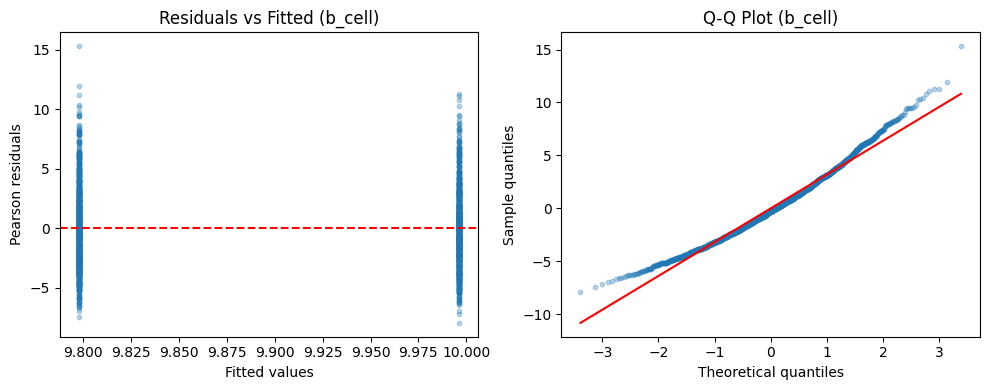

In [38]:
## Assumption Check 2: Residual Analysis (Mean Model / Link Function)
# Pearson residuals vs fitted — no systematic pattern = link function is appropriate
# Q-Q plot — check approximate normality of residuals

# Use exchangeable (common choice for repeated measures with no obvious time-decay)
pop_df = freq[freq.population == "b_cell"].copy()
m = GEE.from_formula("percentage ~ response", groups="subject_id",
                      data=pop_df, family=Gaussian(), cov_struct=Exchangeable())
result = m.fit()

pearson_resid = result.resid_pearson
fitted        = result.fittedvalues

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].scatter(fitted, pearson_resid, alpha=0.3, s=10)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Fitted values")
axes[0].set_ylabel("Pearson residuals")
axes[0].set_title("Residuals vs Fitted (b_cell)")

(osm, osr), (slope, intercept, _) = scipy_stats.probplot(pearson_resid)
axes[1].scatter(osm, osr, alpha=0.3, s=10)
axes[1].plot(osm, slope * np.array(osm) + intercept, color="red")
axes[1].set_xlabel("Theoretical quantiles")
axes[1].set_ylabel("Sample quantiles")
axes[1].set_title("Q-Q Plot (b_cell)")

plt.tight_layout()
plt.show()



In [53]:
## Assumption Check 3: Robust vs Naive SE comparison (b_cell)
# If robust SE >> naive SE → correlation structure is wrong
# If ratio ≈ 1.0 → working correlation is reasonable

naive_se = pd.Series(np.sqrt(np.diag(result.cov_naive)), index=result.params.index)
se_compare = pd.DataFrame({
    "coef":      result.params,
    "robust_se": result.bse,
    "naive_se":  naive_se,
    "ratio":     (result.bse / naive_se).round(3),
}).round(4)
print(se_compare.to_string())
print("\nRatio close to 1.0 = working correlation structure is appropriate")

                         coef  robust_se  naive_se  ratio
Intercept              9.0975     0.5551    0.5466  1.015
response[T.yes]        0.2028     0.2210    0.2288  0.966
sex[T.M]               0.3167     0.1423    0.1419  1.003
C(project_id)[T.prj3] -0.2278     0.1417    0.1435  0.987
time                   0.0238     0.0174    0.0182  0.956
response[T.yes]:time  -0.0614     0.0256    0.0257  0.996
age                    0.0105     0.0085    0.0081  1.044

Ratio close to 1.0 = working correlation structure is appropriate


In [ ]:
import pandas as pd
from statsmodels.stats.multitest import multipletests
from analysis.db import CELL_TYPES

# GEE: percentage ~ response * time + sex + age + C(project_id)
# coef_response  = difference at day 0 (baseline) — relevant for prediction
# coef_resp:time = change in gap per day (trajectory)
# coef_at_day7   = coef_response + 7 * coef_resp:time (derived, no re-fitting)

rows = []
for pop in CELL_TYPES:
    pop_df = freq[freq.population == pop].copy()

    m = GEE.from_formula(
        "percentage ~ response * time + sex + age + C(project_id)",
        groups="subject_id",
        data=pop_df,
        family=Gaussian(),
        cov_struct=Exchangeable(),
    )
    r = m.fit()
    rho = float(r.cov_struct.dep_params)
    print(f"{pop:>12}  ρ = {rho:.4f}")

    coef_resp = r.params.get("response[T.yes]",      float("nan"))
    coef_traj = r.params.get("response[T.yes]:time", float("nan"))
    rows.append({
        "population":     pop,
        "coef_response":  round(coef_resp, 4),
        "p_response":     round(r.pvalues.get("response[T.yes]",      float("nan")), 4),
        "coef_resp:time": round(coef_traj, 4),
        "p_resp:time":    round(r.pvalues.get("response[T.yes]:time", float("nan")), 4),
        "coef_at_day7":   round(coef_resp + 7 * coef_traj, 4),
    })

results_df = pd.DataFrame(rows)

# BH FDR across 10 tests (5 populations × 2 key terms)
all_p = results_df["p_response"].tolist() + results_df["p_resp:time"].tolist()
_, all_p_adj, _, _ = multipletests(all_p, method="fdr_bh")
results_df["p_adj_response"]  = [round(p, 4) for p in all_p_adj[:5]]
results_df["p_adj_resp:time"] = [round(p, 4) for p in all_p_adj[5:]]
results_df["sig_response"]    = all_p_adj[:5] < 0.05
results_df["sig_resp:time"]   = all_p_adj[5:] < 0.05

print()
print("Summary table (reference = day 0 baseline):")
print(results_df.to_string(index=False))
print()
print("Note — coef_at_day7 = coef_response + 7 × coef_resp:time (effect at treatment midpoint, derived)")

In [55]:
# Robustness check: Independence vs Exchangeable
# With ρ ≈ 0, both structures should give virtually identical coefficients and p-values
# Difference in SEs tells you how much the correlation assumption matters here

pop_df = freq[freq.population == "b_cell"].copy()
pop_df["time_c"] = pop_df["time"] - 7

rows_robust = []
for name, struct in [("Exchangeable", Exchangeable()), ("Independence", Independence())]:
    m = GEE.from_formula(
        "percentage ~ response * time_c + sex + age + C(project_id)",
        groups="subject_id",
        data=pop_df,
        family=Gaussian(),
        cov_struct=struct,
    )
    r = m.fit()
    rows_robust.append({
        "structure":      name,
        "coef_response":  round(r.params.get("response[T.yes]",        float("nan")), 4),
        "se_response":    round(r.bse.get("response[T.yes]",           float("nan")), 4),
        "p_response":     round(r.pvalues.get("response[T.yes]",       float("nan")), 4),
        "coef_resp:time": round(r.params.get("response[T.yes]:time_c", float("nan")), 4),
        "se_resp:time":   round(r.bse.get("response[T.yes]:time_c",    float("nan")), 4),
        "p_resp:time":    round(r.pvalues.get("response[T.yes]:time_c",float("nan")), 4),
    })

print("b_cell — Exchangeable vs Independence (robustness check):")
print(pd.DataFrame(rows_robust).to_string(index=False))
print()
print("Within-subject correlation was weak (ρ ≈ 0 under exchangeable structure),")
print("so results are robust across independence and exchangeable working correlations.")

b_cell — Exchangeable vs Independence (robustness check):
   structure  coef_response  se_response  p_response  coef_resp:time  se_resp:time  p_resp:time
Exchangeable        -0.2269       0.1414      0.1087         -0.0614        0.0256       0.0164
Independence        -0.2269       0.1414      0.1087         -0.0614        0.0256       0.0164

Within-subject correlation was weak (ρ ≈ 0 under exchangeable structure),
so results are robust across independence and exchangeable working correlations.


## Conclusion

GEE model: `percentage ~ response * time + sex + age + C(project_id)`  
Cluster: `subject_id` | Family: Gaussian | Correlation: Exchangeable (ρ ≈ 0 across all populations)  
Reference point: **day 0 (baseline)** 
BH FDR correction applied across **10 tests** (5 populations × 2 terms)

---

### Main effect of response at baseline (day 0)

| Population | Coef | p (raw) | p_adj (BH) | Decision |
|---|---|---|---|---|
| b_cell | +0.203 | 0.359 | 0.644 | Fail to reject H₀ |
| cd8_t_cell | −0.206 | 0.531 | 0.644 | Fail to reject H₀ |
| cd4_t_cell | +0.360 | 0.307 | 0.644 | Fail to reject H₀ |
| nk_cell | −0.040 | 0.884 | 0.884 | Fail to reject H₀ |
| monocyte | −0.317 | 0.298 | 0.644 | Fail to reject H₀ |

**No cell population shows a significant difference at baseline between responders and non-responders.** The groups start with similar immune profiles at day 0.

### Response × time interaction (differential trajectory)

| Population | Coef/day | p (raw) | p_adj (BH) | Decision |
|---|---|---|---|---|
| **b_cell** | **−0.061** | **0.016** | **0.164** | Fail to reject H₀ |
| cd8_t_cell | +0.020 | 0.580 | 0.644 | Fail to reject H₀ |
| cd4_t_cell | +0.042 | 0.285 | 0.644 | Fail to reject H₀ |
| nk_cell | −0.026 | 0.412 | 0.644 | Fail to reject H₀ |
| monocyte | +0.025 | 0.482 | 0.644 | Fail to reject H₀ |

---

### Interesting finding at day 7

Although no population differs significantly at baseline, by **day 7 (treatment midpoint)** the groups have diverged. The day 7 effect is derived directly from the model without re-fitting:

> **effect at day 7 = coef_response + 7 × coef_resp:time**

| Population | Coef at day 7 | Interpretation |
|---|---|---|
| b_cell | −0.227 | Responders' B cells have declined relative to non-responders by day 7 |
| **cd4_t_cell** | **+0.654** | **Responders have ~0.65 pp higher CD4 T cell frequency than non-responders at day 7** |

CD4 T cell divergence at day 7 is notable as a signal that emerges during treatment. B cell decline in responders is suggestive but does not survive FDR correction (p_adj = 0.164).

### Overall conclusion

Relative immune cell frequencies **do not predict miraclib response at baseline**. However, CD4 T cells show meaningful divergence by day 7 of treatment, and B cell trajectories show a suggestive (non-significant) differential decline in responders. 